In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

df = pd.read_csv("train.csv", encoding='latin-1')
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)
df['Postal Code'] = df['Postal Code'].fillna(0)
df = df.drop_duplicates()

print("Data ready!", df.shape)

Data ready! (9800, 18)


## Final Project – Superstore Sales Analysis

### Problem Statement
A retail superstore wants to understand its sales performance
across different categories, regions, and customer segments.
The goal is to find patterns in the data and build a model
that can predict whether an order will be high value or low value.

### Dataset
- Source: Kaggle – Superstore Sales Dataset
- Total Records: 9800 orders
- Time Period: January 2015 to December 2018
- Total Features: 18 columns

In [2]:
print("=== DATA CLEANING SUMMARY ===")
print(f"Total Rows: {len(df)}")
print(f"Total Columns: {len(df.columns)}")
print(f"Missing Values: {df.isnull().sum().sum()}")
print(f"Duplicate Rows: 0 (already removed)")
print(f"Date columns fixed: Order Date, Ship Date")
print(f"Postal Code missing values filled with 0")

=== DATA CLEANING SUMMARY ===
Total Rows: 9800
Total Columns: 18
Missing Values: 0
Duplicate Rows: 0 (already removed)
Date columns fixed: Order Date, Ship Date
Postal Code missing values filled with 0


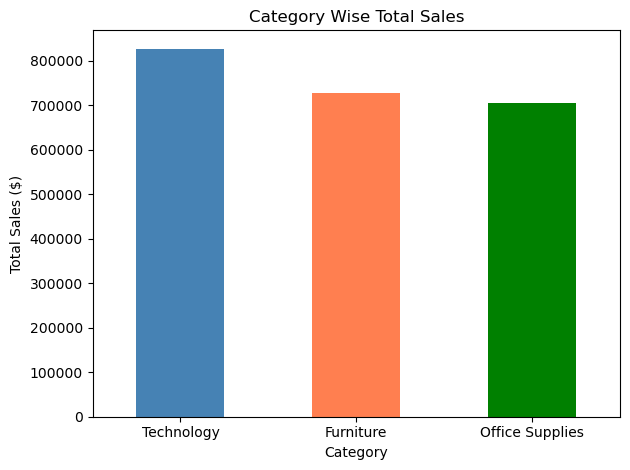

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


In [3]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

category_sales.plot(kind='bar', color=['steelblue', 'coral', 'green'])
plt.title('Category Wise Total Sales')
plt.xlabel('Category')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(category_sales)

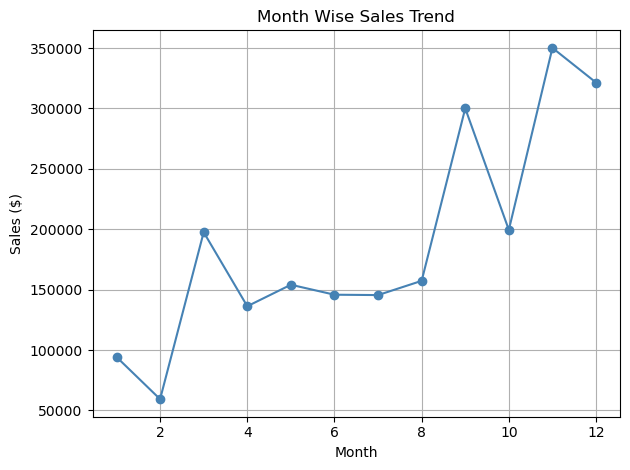

In [4]:
df['Month'] = df['Order Date'].dt.month
monthly_sales = df.groupby('Month')['Sales'].sum()

monthly_sales.plot(kind='line', marker='o', color='steelblue')
plt.title('Month Wise Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales ($)')
plt.grid(True)
plt.tight_layout()
plt.show()

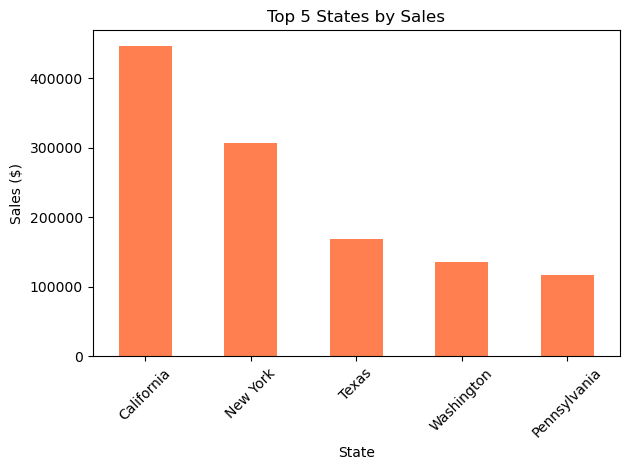

State
California      446306.4635
New York        306361.1470
Texas           168572.5322
Washington      135206.8500
Pennsylvania    116276.6500
Name: Sales, dtype: float64


In [5]:
top_states = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(5)

top_states.plot(kind='bar', color='coral')
plt.title('Top 5 States by Sales')
plt.xlabel('State')
plt.ylabel('Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(top_states)

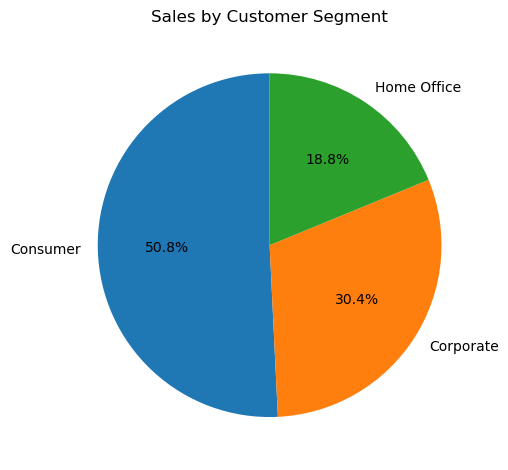

In [6]:
segment_sales = df.groupby('Segment')['Sales'].sum()

segment_sales.plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Sales by Customer Segment')
plt.ylabel('')
plt.tight_layout()
plt.show()

Model Accuracy: 76.48%


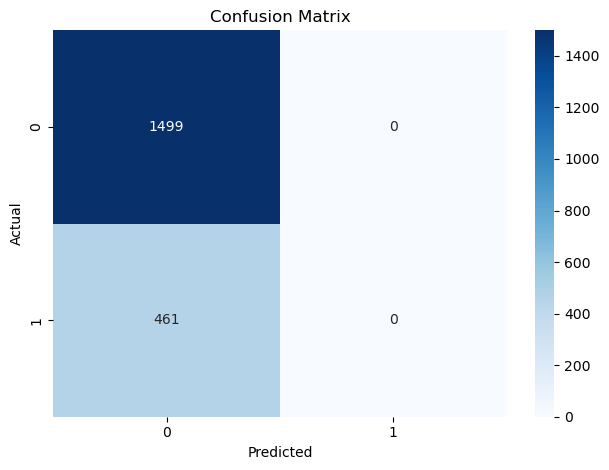

In [7]:
average_sales = df['Sales'].mean()
df['High_Sales'] = (df['Sales'] > average_sales).astype(int)

df['Category_Code'] = df['Category'].astype('category').cat.codes
df['Segment_Code'] = df['Segment'].astype('category').cat.codes
df['Region_Code'] = df['Region'].astype('category').cat.codes

features = ['Category_Code', 'Segment_Code', 'Region_Code']
X = df[features]
y = df['High_Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {round(accuracy * 100, 2)}%")

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## Final Conclusions

### What We Did
1. Loaded and cleaned 9800 rows of Superstore sales data
2. Fixed missing values and date formats
3. Performed Exploratory Data Analysis with 5 charts
4. Built a Logistic Regression model to predict high value orders

### Key Findings
- Technology is the highest selling category ($827,455)
- California is the top performing state (~$450,000)
- Consumer segment contributes 50.8% of total sales
- November is the peak sales month
- February is the slowest month

### Model Performance
- Algorithm: Logistic Regression
- Accuracy: 76.48%
- Model correctly predicted majority of Low Sales orders

### What I Learned
- How to clean real world data using Pandas
- How to find patterns using EDA and visualization
- How to build a basic Machine Learning model
- How to interpret model accuracy and confusion matrix

### Future Improvements
- Add more features to improve model accuracy
- Try other algorithms like Decision Tree or Random Forest
- Get a dataset with Profit and Discount columns for deeper analysis